# Week 8 assignment: NLP on social media data

Take our social media we collected last week and:

- extract the sentiment scores of the titles of the posts
    - you can use the keyword method, Python packages, or other methods to extract the sentiment scores
- plot a histogram of the sentiment scores
- look at descriptive statistics (mean, median, standard deviation) of the sentiment scores
- examine the text for some of the highest and lowest sentiment scores
- write a short analysis of the results and our process, as well as propose one idea for something we could use this data for

Optional advanced challenges:
- Compare different sentiment analysis methods (e.g. textblob and VADER). Does one seem to work better than another?
- Get the sentiments of the comments for each post. We can do a lot with this, such as:
    - look at the average sentiment for each post and compare it with the sentiment of the title and/or text
    - look at the distribution of sentiments for each post and find the posts with the widest range of sentiments (controversial posts)
- Examine the subjectivity of our data (e.g. using textblob)
- Use topic modeling on the posts
    - you can also add in the comments to the topic model
- Look at the most frequent words for positive and negative sentiment posts

Note: There is no assignment solution file for this week.

# Assignment

## Load Data

In [1]:
import sqlite3
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import re
import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('stopwords')
stopwords = stopwords.words('english')

[nltk_data] Downloading package stopwords to /Users/ada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
conn = sqlite3.connect('data/co_reddit.db')
post_df = pd.read_sql_query('SELECT * FROM posts;', conn)
conn.close()

In [4]:
post_df.shape

(1000, 6)

In [5]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.3 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Calculate Sentiment Score

In [6]:
def get_tb_sentiment(text):
    tb = TextBlob(text)
    return tb.sentiment[0]

In [7]:
post_df['tb_sentiment'] = post_df['title'].apply(get_tb_sentiment)

In [8]:
post_df.head()

,title,link,author,num_comments,score,text,tb_sentiment
0,The Nobel Prize in Chemistry 2025: Awarded to ...,/r/science/comments/1o1cp2z/the_nobel_prize_in...,shiruken,10,326,The Nobel Prize in Chemistry 2025 was awarded ...,0.000000
1,The Nobel Prize in Physics 2025: Awarded to Jo...,/r/science/comments/1o0hps8/the_nobel_prize_in...,shiruken,11,377,The Nobel Prize in Physics 2025 was awarded to...,0.000000
2,Major IQ differences in identical twins linked...,/r/science/comments/1o4afve/major_iq_differenc...,mvea,371,8404,,0.132500
3,Researchers took 44 young untrained males and ...,/r/science/comments/1o3tkfs/researchers_took_4...,James_Fortis,531,8353,,-0.053125
4,A large study has found that calcium supplemen...,/r/science/comments/1o4axrz/a_large_study_has_...,-Mystica-,11,525,,0.110317


## Visualize sentiment scores

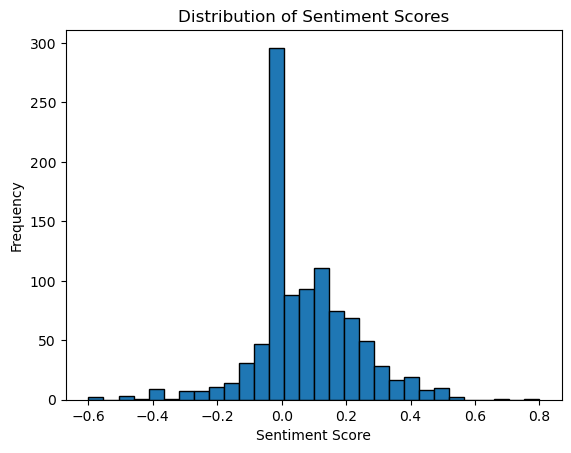

In [9]:
plt.hist(post_df['tb_sentiment'].dropna(), bins=30, edgecolor='k')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

## Calculate descriptive statistics

In [10]:
post_df['tb_sentiment'].describe()

count    1000.000000
mean        0.074313
std         0.156598
min        -0.600000
25%         0.000000
50%         0.050000
75%         0.161742
max         0.800000
Name: tb_sentiment, dtype: float64

In [11]:
mean_sentiment = post_df['tb_sentiment'].mean()
median_sentiment = post_df['tb_sentiment'].median()
std_sentiment = post_df['tb_sentiment'].std()

print(f'Mean Sentiment: {mean_sentiment}')
print(f'Median Sentiment: {median_sentiment}')
print(f'Standard Deviation of Sentiment: {std_sentiment}')

Mean Sentiment: 0.07431272323432739
Median Sentiment: 0.05
Standard Deviation of Sentiment: 0.15659790181325237


## Examine high and low sentiment posts

In [12]:
max_sentiment_post = post_df['tb_sentiment'].idxmax()
min_sentiment_post = post_df['tb_sentiment'].idxmin()

In [13]:
print("Post with Highest Sentiment Score:")
print(post_df.loc[max_sentiment_post, 'title'])

print("\nPost with Lowest Sentiment Score:")
print(post_df.loc[min_sentiment_post, 'title'])

Post with Highest Sentiment Score:
Curcumin Induces Transgenerational and Sex‐Specific Effects on Lifespan, Gene Expression, and Metabolism in the Fruit Fly Drosophila melanogaster

Post with Lowest Sentiment Score:
Dangerous ‘nitazene’ opioids are on the rise: researchers are worried


## Summary
We have successfully loaded the social media data from a SQLite database. We then calculated sentiment scores for the post titles using the TextBlob library. We visualized the distribution of these sentiment scores using a histogram and examined the descriptive statistics (mean, median, and standard deviation).

The distribution of TextBlob sentiment scores appears to be slightly skewed towards positive values, with a mean of approximately 0.074 and a median of 0.05. The standard deviation of around 0.157 suggests a moderate spread in sentiment.

Finally, we identified and printed the titles of the posts with the highest and lowest sentiment scores according to TextBlob:

* **Post with Highest Sentiment Score:** Curcumin Induces Transgenerational and Sex‐Specific Effects on Lifespan, Gene Expression, and Metabolism in the Fruit Fly Drosophila melanogaster
* **Post with Lowest Sentiment Score:** Dangerous ‘nitazene’ opioids are on the rise: researchers are worried

# Optional Tasks

## Compare with Vader Score

### Calculate sentiment scores (vader)

In [14]:
def vader_sentiment(text):
    analyzer = SentimentIntensityAnalyzer()
    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']

In [15]:
#apply vader to the whole df
post_df['vader_sentiment'] = post_df['title'].apply(vader_sentiment)

In [16]:
post_df.head()

,title,link,author,num_comments,score,text,tb_sentiment,vader_sentiment
0,The Nobel Prize in Chemistry 2025: Awarded to ...,/r/science/comments/1o1cp2z/the_nobel_prize_in...,shiruken,10,326,The Nobel Prize in Chemistry 2025 was awarded ...,0.000000,0.7184
1,The Nobel Prize in Physics 2025: Awarded to Jo...,/r/science/comments/1o0hps8/the_nobel_prize_in...,shiruken,11,377,The Nobel Prize in Physics 2025 was awarded to...,0.000000,0.7964
2,Major IQ differences in identical twins linked...,/r/science/comments/1o4afve/major_iq_differenc...,mvea,371,8404,,0.132500,0.0772
3,Researchers took 44 young untrained males and ...,/r/science/comments/1o3tkfs/researchers_took_4...,James_Fortis,531,8353,,-0.053125,0.3208
4,A large study has found that calcium supplemen...,/r/science/comments/1o4axrz/a_large_study_has_...,-Mystica-,11,525,,0.110317,0.7269


In [17]:
# calculate descriptive statistics for vader sentiment
vader_mean = post_df['vader_sentiment'].mean()
vader_median = post_df['vader_sentiment'].median()
vader_std = post_df['vader_sentiment'].std()

print(f'Mean Sentiment: {vader_mean}')
print(f'Median Sentiment: {vader_median}')
print(f'Standard Deviation of Sentiment: {vader_std}')

Mean Sentiment: -0.005522299999999996
Median Sentiment: 0.0
Standard Deviation of Sentiment: 0.48323005780008293


### Compare sentiment scores

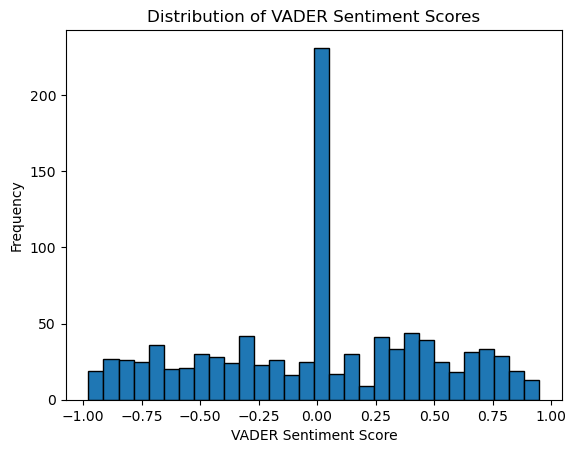

In [18]:
plt.hist(post_df['vader_sentiment'].dropna(), bins=30, edgecolor='k')
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('VADER Sentiment Score')
plt.ylabel('Frequency')
plt.show()

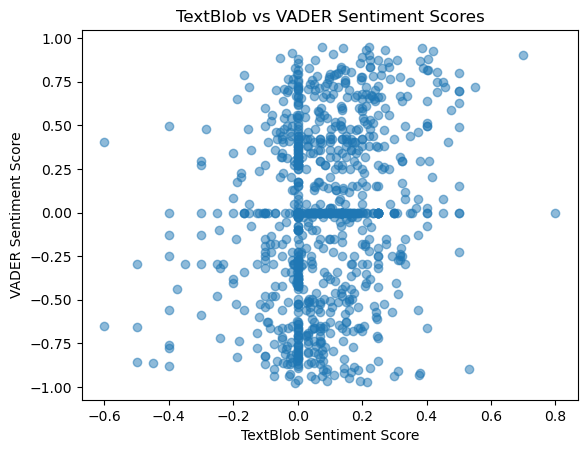

In [19]:
plt.scatter(post_df['tb_sentiment'], post_df['vader_sentiment'], alpha=0.5)
plt.title('TextBlob vs VADER Sentiment Scores')
plt.xlabel('TextBlob Sentiment Score')
plt.ylabel('VADER Sentiment Score')
plt.show()

In [20]:
correlation_posts = post_df[['tb_sentiment', 'vader_sentiment']].corr()
print(correlation_posts)

                 tb_sentiment  vader_sentiment
tb_sentiment          1.00000          0.23589
vader_sentiment       0.23589          1.00000


### High and Low sentiment posts

In [21]:
max_vader_post = post_df['vader_sentiment'].idxmax()
min_vader_post = post_df['vader_sentiment'].idxmin()

print("Post with Highest TextBlob Sentiment Score:")
print(post_df.loc[max_sentiment_post, 'title'])

print("\nPost with Lowest TextBlob Sentiment Score:")
print(post_df.loc[min_sentiment_post, 'title'])

print("\nPost with Highest VADER Sentiment Score:")
print(post_df.loc[max_vader_post, 'title'])

print("\nPost with Lowest VADER Sentiment Score:")
print(post_df.loc[min_vader_post, 'title']) 


Post with Highest TextBlob Sentiment Score:
Curcumin Induces Transgenerational and Sex‐Specific Effects on Lifespan, Gene Expression, and Metabolism in the Fruit Fly Drosophila melanogaster

Post with Lowest TextBlob Sentiment Score:
Dangerous ‘nitazene’ opioids are on the rise: researchers are worried

Post with Highest VADER Sentiment Score:
Nineteen children (from newborns to teens) with heart conditions receive partial heart transplants using live donor heart valves. The valves grow with the children, work across many congenital heart conditions, may cut down need for future operations and immunosuppressants.

Post with Lowest VADER Sentiment Score:
Catastrophic wildfires surge globally with 43 per cent of worst disasters in past decade. Analysing 44 years of disaster data, researchers found economic disasters increased more than four times and fatal disasters causing 10 or more deaths tripled since 1980


### Comparison Summary

We have calculated sentiment scores for the post titles using VADER sentiment analysis as well.

The VADER sentiment scores have a wider range and a standard deviation that is significantly larger than TextBlob's, suggesting that VADER provides more varied sentiment scores for this dataset. The mean sentiment for VADER is slightly negative, while TextBlob's is slightly positive.

The correlation between the TextBlob and VADER sentiment scores for the post titles is approximately 0.236. This indicates a weak positive correlation, meaning that while there is some agreement between the two methods, they often produce different sentiment scores for the same post title.

## Comments Sentiment Score

### Load comments data

In [22]:
conn = sqlite3.connect('data/reddit_data.sqlite')
# conn = sqlite3.connect('data/co_reddit.sqlite')
comments_df = pd.read_sql_query('SELECT * FROM comments;', conn)
c_post_df =  pd.read_sql_query('SELECT * FROM posts;', conn)
conn.close()

In [23]:
comments_df.shape

(16176, 6)

In [24]:
c_post_df.shape

(993, 8)

In [25]:
c_post_df.head()

,index,title,link,author,num_comments,score,text,id
0,0,Fear of supernatural punishment can harmonize ...,/r/science/comments/1o9lr38/fear_of_supernatur...,calliope_kekule,11,40,,1o9lr38
1,1,Americans’ attitudes toward immigration shaped...,/r/science/comments/1o9g9r6/americans_attitude...,mvea,103,607,,1o9g9r6
2,2,“Reminiscence bump” is our tendency to form st...,/r/science/comments/1o9f43f/reminiscence_bump_...,mvea,81,1264,,1o9f43f
3,3,TV-viewing and gaming were associated with inc...,/r/science/comments/1o9dqyw/tvviewing_and_gami...,Dr_Neurol,12,222,,1o9dqyw
4,4,Mobile gaming worsens student performance and ...,/r/science/comments/1o9cqtb/mobile_gaming_wors...,smurfyjenkins,10,69,,1o9cqtb


In [26]:
comments_df.head()

,index,author,score,text,post_id,comment_id
0,0,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o9lr38,nk36hvu
1,1,sweetnsourgrapes,22,> The current study aimed to build a mathemati...,1o9lr38,nk38d5o
2,2,SaintValkyrie,6,It should be known that doing things purely ou...,1o9lr38,nk3bcu6
3,3,belayg3pulp2025,1,"I'm not sure I completely buy that, to be hone...",1o9lr38,nk3kwot
4,4,mvea,1,Reposted with updated post title edited to fit...,1o9g9r6,nk20j2l


### Calculate sentiment scores for comments

In [27]:
c_post_df['sentiment_tb'] = c_post_df['title'].apply(get_tb_sentiment)
c_post_df['sentiment_vader'] = c_post_df['title'].apply(vader_sentiment)

In [28]:
comments_df['sentiment_tb'] = comments_df['text'].apply(get_tb_sentiment)
comments_df['sentiment_vader'] = comments_df['text'].apply(vader_sentiment)

In [29]:
# sentiment scores by post
average_comment_sentiment =comments_df.groupby('post_id')[['sentiment_tb', 'sentiment_vader']].mean().reset_index()
average_comment_sentiment.head()

,post_id,sentiment_tb,sentiment_vader
0,1n4w9tx,0.086967,0.011425
1,1n4wz9k,-0.235255,-0.197175
2,1n4xidp,-0.062238,-0.005123
3,1n4xqmt,0.082634,0.210467
4,1n4xueb,0.351250,0.662450


### Average sentiment for each post and compare it with the sentiment of the title

In [30]:
c_post_df.rename(columns={'id': 'post_id'}, inplace=True)
merged_pc_df = pd.merge(c_post_df, average_comment_sentiment, on='post_id', how='left', suffixes=('_post', '_comments'))
merged_pc_df.head()

,index,title,link,author,num_comments,score,text,post_id,sentiment_tb_post,sentiment_vader_post,sentiment_tb_comments,sentiment_vader_comments
0,0,Fear of supernatural punishment can harmonize ...,/r/science/comments/1o9lr38/fear_of_supernatur...,calliope_kekule,11,40,,1o9lr38,0.066667,-0.5719,0.137100,0.425175
1,1,Americans’ attitudes toward immigration shaped...,/r/science/comments/1o9g9r6/americans_attitude...,mvea,103,607,,1o9g9r6,0.335374,0.9382,0.226925,0.322671
2,2,“Reminiscence bump” is our tendency to form st...,/r/science/comments/1o9f43f/reminiscence_bump_...,mvea,81,1264,,1o9f43f,-0.022222,0.3182,0.175520,0.455254
3,3,TV-viewing and gaming were associated with inc...,/r/science/comments/1o9dqyw/tvviewing_and_gami...,Dr_Neurol,12,222,,1o9dqyw,-0.066667,0.2732,0.077708,0.025525
4,4,Mobile gaming worsens student performance and ...,/r/science/comments/1o9cqtb/mobile_gaming_wors...,smurfyjenkins,10,69,,1o9cqtb,0.040000,-0.0772,0.088125,0.073275


In [31]:
# Fill NaN values in average comment sentiment with 0
merged_pc_df['sentiment_tb_comments'].fillna(0, inplace=True)
merged_pc_df['sentiment_vader_comments'].fillna(0, inplace=True)

In [32]:
# Calculate correlations
correlation_merged_tb = merged_pc_df[['sentiment_tb_post', 'sentiment_tb_comments']].corr()
correlation_merged_vader = merged_pc_df[['sentiment_vader_post', 'sentiment_vader_comments']].corr()

display(correlation_merged_tb)
display(correlation_merged_vader)

,sentiment_tb_post,sentiment_tb_comments
sentiment_tb_post,1.000000,0.006886
sentiment_tb_comments,0.006886,1.000000


,sentiment_vader_post,sentiment_vader_comments
sentiment_vader_post,1.000000,0.298057
sentiment_vader_comments,0.298057,1.000000


In [33]:
# Display titles with highest and lowest average comment sentiment
max_tb_comments_post = merged_pc_df['sentiment_tb_comments'].idxmax()
min_tb_comments_post = merged_pc_df['sentiment_tb_comments'].idxmin()
max_vader_comments_post = merged_pc_df['sentiment_vader_comments'].idxmax()
min_vader_comments_post = merged_pc_df['sentiment_vader_comments'].idxmin()

print("Post with Highest TextBlob Sentiment Score:")
print(merged_pc_df.iloc[max_tb_comments_post]['title'])

print("\nPost with Lowest TextBlob Sentiment Score:")
print(merged_pc_df.iloc[min_tb_comments_post]['title'])

print("\nPost with Highest VADER Sentiment Score:")
print(merged_pc_df.iloc[max_vader_comments_post]['title'])

print("\nPost with Lowest VADER Sentiment Score:")
print(merged_pc_df.iloc[min_vader_comments_post]['title'])

Post with Highest TextBlob Sentiment Score:
Hormone Therapy Found Safe for the Hearts of Women Below Age 60 Experiencing Symptoms of Menopause

Post with Lowest TextBlob Sentiment Score:
ChatGPT conversations only slightly reduce climate scepticism, and the effects fade over time

Post with Highest VADER Sentiment Score:
Astronomers Discover Massive Molecular Cloud Hidden in Milky Way. The Giant Molecular Cloud (GMC) is about 60 parsecs—or 200 light years—long.

Post with Lowest VADER Sentiment Score:
Study shows how domestic abusers build ‘trauma bonds’ with victims before violence begins


In [34]:
# Calculate standard deviation of comment sentiment
comment_sentiment_std = comments_df.groupby('post_id')[['sentiment_tb', 'sentiment_vader']].std().reset_index()
comment_sentiment_std.rename(columns={'sentiment_tb': 'std_sentiment_tb', 'sentiment_vader': 'std_sentiment_vader'}, inplace=True)
comment_sentiment_std.head()


,post_id,std_sentiment_tb,std_sentiment_vader
0,1n4w9tx,0.185272,0.906527
1,1n4wz9k,0.346073,0.663505
2,1n4xidp,0.312675,0.476462
3,1n4xqmt,0.111996,1.044689
4,1n4xueb,0.210364,0.128057


In [35]:
# Merge standard deviation with the main DataFrame
merged_pc_df = pd.merge(merged_pc_df, comment_sentiment_std, on='post_id', how='left')
merged_pc_df.head()

,index,title,link,author,num_comments,score,text,post_id,sentiment_tb_post,sentiment_vader_post,sentiment_tb_comments,sentiment_vader_comments,std_sentiment_tb,std_sentiment_vader
0,0,Fear of supernatural punishment can harmonize ...,/r/science/comments/1o9lr38/fear_of_supernatur...,calliope_kekule,11,40,,1o9lr38,0.066667,-0.5719,0.137100,0.425175,0.087120,0.709634
1,1,Americans’ attitudes toward immigration shaped...,/r/science/comments/1o9g9r6/americans_attitude...,mvea,103,607,,1o9g9r6,0.335374,0.9382,0.226925,0.322671,0.248876,0.529100
2,2,“Reminiscence bump” is our tendency to form st...,/r/science/comments/1o9f43f/reminiscence_bump_...,mvea,81,1264,,1o9f43f,-0.022222,0.3182,0.175520,0.455254,0.208515,0.355732
3,3,TV-viewing and gaming were associated with inc...,/r/science/comments/1o9dqyw/tvviewing_and_gami...,Dr_Neurol,12,222,,1o9dqyw,-0.066667,0.2732,0.077708,0.025525,0.088672,0.498989
4,4,Mobile gaming worsens student performance and ...,/r/science/comments/1o9cqtb/mobile_gaming_wors...,smurfyjenkins,10,69,,1o9cqtb,0.040000,-0.0772,0.088125,0.073275,0.103991,0.462862


In [36]:
# Identify post with the highest standard deviation of comment sentiment, indicating diverse opinions
merged_pc_std_tb_post = merged_pc_df.dropna(subset=['std_sentiment_tb'])
merged_pc_std_vader_post = merged_pc_df.dropna(subset=['std_sentiment_vader'])


In [37]:
if not merged_pc_std_tb_post.empty:
    max_std_tb_post = merged_pc_std_tb_post['std_sentiment_tb'].idxmax()
    print("Post with Highest Standard Deviation in TextBlob Comment Sentiment:")
    print(merged_pc_std_tb_post.loc[max_std_tb_post, 'title'])
else:
    print("No posts with valid TextBlob comment sentiment standard deviation found.")

if not merged_pc_std_vader_post.empty:  
    max_std_vader_post = merged_pc_std_vader_post['std_sentiment_vader'].idxmax()
    print("\nPost with Highest Standard Deviation in VADER Comment Sentiment:")
    print(merged_pc_std_vader_post.loc[max_std_vader_post, 'title'])
else:
    print("\nNo posts with valid VADER comment sentiment standard deviation found.")

Post with Highest Standard Deviation in TextBlob Comment Sentiment:
Study on mouse models of Alzheimer’s disease found that inhibiting the function of a key protein in the circadian system can decrease levels of harmful tau proteins and reduce neurodegeneration.

Post with Highest Standard Deviation in VADER Comment Sentiment:
Catastrophic wildfires surge globally with 43 per cent of worst disasters in past decade. Analysing 44 years of disaster data, researchers found economic disasters increased more than four times and fatal disasters causing 10 or more deaths tripled since 1980


### Summary Sentiment scores for comments

Comparing the average comment sentiment with the post title sentiment showed a weak correlation for both TextBlob (correlation ~0.007) and a moderate positive correlation for VADER (correlation ~0.298). This suggests that the sentiment expressed in the comments is not strongly aligned with the sentiment of the post title, particularly when using TextBlob.

We also calculated the standard deviation of comment sentiment for each post using both TextBlob and VADER. A high standard deviation indicates a wider range of sentiment among the comments for a particular post, potentially identifying controversial posts. We identified the posts with the highest standard deviation in comment sentiment for both methods.

## Examine subjectivity

In [38]:
merged_pc_df['title_subjectivity'] = merged_pc_df['title'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
comments_df['comment_subjectivity'] = comments_df['text'].fillna('').astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [39]:
print("Descriptive Statistics for Title Subjectivity:")
print(merged_pc_df[ 'title_subjectivity'].describe())

print("\nDescriptive Statistics for Comment Subjectivity:")
print(comments_df['comment_subjectivity'].describe())

Descriptive Statistics for Title Subjectivity:
count    993.000000
mean       0.367910
std        0.235920
min        0.000000
25%        0.212500
50%        0.391667
75%        0.506909
max        1.000000
Name: title_subjectivity, dtype: float64

Descriptive Statistics for Comment Subjectivity:
count    16176.000000
mean         0.406025
std          0.262107
min          0.000000
25%          0.233333
50%          0.454545
75%          0.555023
max          1.000000
Name: comment_subjectivity, dtype: float64


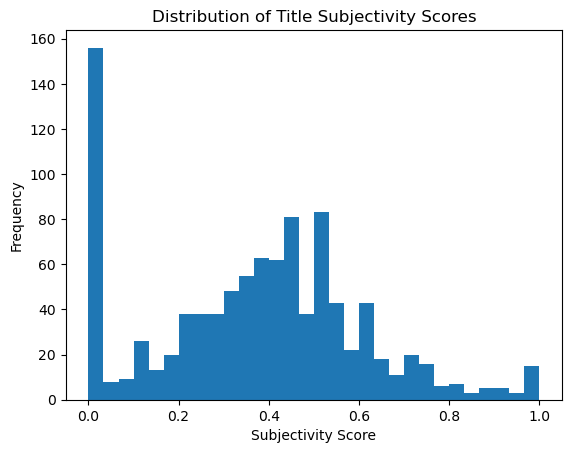

In [40]:
plt.hist(merged_pc_df['title_subjectivity'].dropna(), bins=30)
plt.title('Distribution of Title Subjectivity Scores')
plt.xlabel('Subjectivity Score')
plt.ylabel('Frequency')
plt.show()

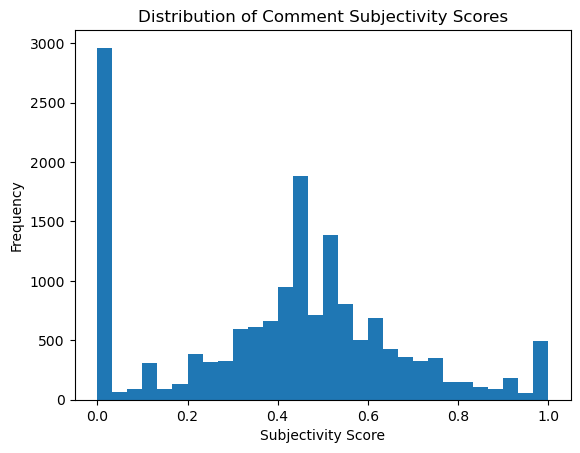

In [41]:
plt.hist(comments_df['comment_subjectivity'].dropna(), bins=30)
plt.title('Distribution of Comment Subjectivity Scores')
plt.xlabel('Subjectivity Score')
plt.ylabel('Frequency')
plt.show()

### Subjectivity Summary

* **Post Title Subjectivity:** The mean subjectivity is approximately 0.368, with a standard deviation of 0.236. The scores range from 0 to 1, with the median around 0.392. This suggests that post titles tend to be somewhat objective, but with a fair amount of variation.
* **Comment Subjectivity:** The mean subjectivity is approximately 0.406, with a standard deviation of 0.262. The scores range from 0 to 1, with the median around 0.455. Comments appear to be slightly more subjective on average than post titles, with a similar spread of scores.

The histograms of subjectivity scores for both titles and comments show a distribution skewed towards lower (more objective) scores, but with a significant number of posts and comments exhibiting higher subjectivity.

## Topic Modeling

In [42]:
def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^A-Za-z\s]', '', text)  # remove non-alphabetic characters
    text = text.lower()  # convert to lowercase
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords]  # remove stopwords

    return ' '.join(tokens)

In [43]:
# Combine title and selftext for posts
merged_pc_df['combined_text'] = merged_pc_df['title'].fillna('') + ' ' + merged_pc_df['text'].fillna('')
merged_pc_df['processed_text'] = merged_pc_df['combined_text'].apply(preprocess_text)
comments_df['processed_text'] = comments_df['text'].fillna('').apply(preprocess_text)

In [44]:
# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')

# Vectorize post texts
post_tfidf = vectorizer.fit_transform(merged_pc_df['processed_text'])

# Initialize LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=10, random_state=42)

# Fit LatentDirichletAllocation to post texts
lda.fit(post_tfidf)

LatentDirichletAllocation(random_state=42)

In [45]:
featue_names = vectorizer.get_feature_names_out()

n_top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}:")
    print(" ".join([featue_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

Topic 0:
new study health researchers brain people women species better shows

Topic 1:
new study researchers children immune finds older treatment shows human

Topic 2:
study new brain red finds patients ai mice students people

Topic 3:
new study risk finds cells time higher evidence research health

Topic 4:
blood time disease body researchers test aging parents evidence new

Topic 5:
new study gut finds research depression light review use quantum

Topic 6:
reveals cancer ancient scientists dna researchers new help study men

Topic 7:
study new human early cognitive researchers scientists science men years

Topic 8:
study new people dementia scientists women change detection climate political

Topic 9:
study shows research anxiety new chronic linked violence people sleep



In [46]:
# same for comments
comment_tfidf = vectorizer.fit_transform(comments_df['processed_text'])
lda.fit(comment_tfidf)

LatentDirichletAllocation(random_state=42)

In [47]:
featue_names = vectorizer.get_feature_names_out()

n_top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}:")
    print(" ".join([featue_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

Topic 0:
yeah like water im thank plastic white wasnt study started

Topic 1:
people im thats time dont like sleep sure good years

Topic 2:
removed apply comments user discussion order personal comment people rscience

Topic 3:
time like daylight known savings best wait scientists warming global

Topic 4:
im years like time people dont work sense didnt think

Topic 5:
like people dont kids cancer im told bad anxiety theyre

Topic 6:
deleted diet bmi fat people study weight health like good

Topic 7:
study article dementia people like age published im great journal

Topic 8:
people like right left dont im political social autism reddit

Topic 9:
people dont like alcohol women study use time men know



### Summary Topic Modeling

For the post titles, the LDA model identified several topics with recurring words related to scientific research, health, disease, and specific fields like neuroscience and genetics. The topics suggest that the posts cover a broad range of scientific subjects, with a focus on new studies, findings, and their implications for human health and understanding.

For the comments, the topics identified by the LDA model appear to be more conversational and opinion-based. Recurring words include terms related to personal opinions ("like", "don't think"), discussions about specific topics mentioned in posts (e.g., "diet", "weight", "climate"), and meta-discussions about the platform itself ("r/science", "comments"). 

Comparing the topics from post titles and comments, it's evident that while post titles focus on presenting research findings, the comments delve into discussions, personal interpretations, and related experiences

## Analyze frequent words by sentiment

In [48]:
# filter posts by sentiment
positive_posts = merged_pc_df[merged_pc_df['sentiment_tb_post'] > 0]
negative_posts = merged_pc_df[merged_pc_df['sentiment_tb_post'] < 0]

In [49]:
# Combine cleaned text for positive and negative posts
positive_text = ' '.join(positive_posts['processed_text'])
negative_text = ' '.join(negative_posts['processed_text'])

In [50]:
# Use CountVectorizer to find most frequent words
vectorizer = CountVectorizer(stop_words='english')

In [51]:
# for positive words
if positive_text:
    positive_counts = vectorizer.fit_transform([positive_text])
    positive_sum = positive_counts.sum(axis=0)
    positive_words_freq = [(word, positive_sum[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    positive_words_freq = sorted(positive_words_freq, key=lambda x: x[1], reverse=True)

    print("Most Common Words in Positive Posts:")
    for word, freq in positive_words_freq[:20]:
        print(f"{word}: {freq}")
else:
    print("No positive posts found.")

print("\n" + "-" * 20 + "\n")


# for negative words
if negative_text:
    negative_counts = vectorizer.fit_transform([negative_text])
    negative_sum = negative_counts.sum(axis=0)
    negative_words_freq = [(word, negative_sum[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    negative_words_freq = sorted(negative_words_freq, key=lambda x: x[1], reverse=True)

    print("\nMost Common Words in Negative Posts:")
    for word, freq in negative_words_freq[:20]:
        print(f"{word}: {freq}")
else:
    print("\nNo negative posts found.")

Most Common Words in Positive Posts:
new: 191
study: 187
finds: 68
people: 65
research: 55
researchers: 54
brain: 53
risk: 52
shows: 46
higher: 45
scientists: 42
health: 41
social: 40
time: 36
children: 36
likely: 36
cells: 36
women: 33
linked: 32
life: 31

--------------------


Most Common Words in Negative Posts:
study: 44
new: 31
researchers: 28
health: 21
people: 21
years: 18
risk: 18
brain: 16
scientists: 16
social: 14
mental: 14
stress: 14
shows: 14
research: 13
use: 11
artificial: 11
cancer: 11
cells: 11
finds: 11
climate: 9


### Summary of Frequent Words by Sentiment

Comparing the two lists, words like "new", "study", "researchers", "health", "people", "risk", "brain", "scientists", "social", "shows", and "research" appear in the top 20 for both positive and negative posts, indicating these are common terms in the dataset regardless of sentiment. However, some words are more prominent in one category, such as "finds", "higher", "children", "likely", "women", and "life" in positive posts, and "years", "mental", "stress", "use", "artificial", "cancer", and "climate" in negative posts. This suggests that while the core topics of the posts might overlap, the specific framing and context can influence the sentiment.

# Summary

In this notebook, we performed a natural language processing analysis on social media data, focusing on sentiment, subjectivity, and topics. We used TextBlob and VADER to analyze the sentiment of post titles and comments, finding a weak correlation between the two methods for post titles and a slightly stronger one for the relationship between post title and comment sentiment. We also examined the subjectivity of the text, noting that comments tend to be slightly more subjective than post titles. Topic modeling revealed distinct themes in post titles (scientific research) and comments (conversational and opinion-based discussions). Finally, analyzing frequent words by sentiment showed overlapping core topics but also highlighted words that appear more often in positive or negative posts, suggesting that framing influences sentiment.

We could use this data for is to predict post popularity (e.g., score or number of comments) based on sentiment, subjectivity, and identified topics. This could help content creators understand what types of posts are more likely to engage the audience and receive higher interaction. We could build a regression model using features derived from our sentiment, subjectivity, and topic modeling analysis to predict post score or comment count.